### H1 — Biological overlap. Adverse pairs show greater target and pathway overlap than non-interacting pairs. Measured as Jaccard/Tanimoto index of target sets, enzyme sets, and SMPDB pathway sets, reported separately.

## Jaccard index ignore f00, and only considers non 0 matches (f11/(f10+f01+f11))

# Documentation: https://www.rdkit.org/docs/source/rdkit.Chem.rdFingerprintGenerator.html

In [1]:
# Imports
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import seaborn as sns

# Morgan fingerprints are generated in batch_smiles_to_fingerprints via AllChem.GetMorganFingerprintAsBitVect

In [2]:
def _smiles_to_morgan_fp(smiles, radius=2, n_bits=2048):
    """Convert one SMILES string to an RDKit Morgan fingerprint (ExplicitBitVect)."""
    if pd.isna(smiles) or not isinstance(smiles, str): # 
        return None

    smiles = smiles.strip()
    if not smiles:
        return None

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)


def batch_smiles_to_fingerprints(smiles_series, radius=2, n_bits=2048, verbose=False):
    """Convert a pandas Series of SMILES strings into a row-aligned list of Morgan fingerprints."""
    fingerprints_list = [
        _smiles_to_morgan_fp(smiles, radius=radius, n_bits=n_bits)
        for smiles in smiles_series
    ]

    if verbose:
        skipped_count = sum(fp is None for fp in fingerprints_list)
        if skipped_count > 0:
            print(f"Skipped invalid/empty SMILES in batch: {skipped_count}")

    return fingerprints_list


def batch_smiles_extraction(
    data_file_path,
    chunk_size,
    drug_a_col,
    drug_b_col,
    verify_total_rows=False,
    verbose=True,
    radius=2,
    n_bits=2048,
):
    """
    Stream input in chunks and convert Drug A/Drug B SMILES columns to Morgan fingerprints.
    Returns two row-aligned fingerprint lists for downstream similarity computation.
    """
    fingerprints_drug_a = [] # A list to hold the Morgan fingerprints for Drug A, where each fingerprint corresponds to a row in the input data file
    fingerprints_drug_b = [] # A list to hold the Morgan fingerprints for Drug B, where each fingerprint corresponds to a row in the input data file
    total_rows_processed = 0 # A counter to keep track of the total number of rows processed across all chunks
    chunk_count = 0 # A counter to keep track of the number of chunks processed from the input data file\\
    
    df = pd.read_parquet(
    data_file_path,
    columns=[drug_a_col, drug_b_col],
    engine='pyarrow'
    )

    for start in range(0, len(df), chunk_size):
        chunk = df.iloc[start:start + chunk_size]

 
        chunk_count += 1 # Increment the chunk counter to reflect that a new chunk of data has been read and is being processed
        rows_in_chunk = len(chunk) # Get the number of rows in the current chunk to update the total rows processed
        total_rows_processed += rows_in_chunk # Update the total number of rows processed by adding the number of rows in the current chunk


        # Generate Morgan fingerprints for Drug A and Drug B SMILES in the current chunk
        chunk_fp_a = batch_smiles_to_fingerprints(
            chunk[drug_a_col],
            radius=radius,
            n_bits=n_bits,
            verbose=False,
        )
        chunk_fp_b = batch_smiles_to_fingerprints(
            chunk[drug_b_col],
            radius=radius,
            n_bits=n_bits,
            verbose=False,
        )

        # Append the fingerprints from the current chunk to the overall lists for Drug A and Drug B
        fingerprints_drug_a.extend(chunk_fp_a)
        fingerprints_drug_b.extend(chunk_fp_b)

        if verbose: # If verbose output is enabled, print the progress of chunk processing, including the number of rows processed in the current chunk and the running total of rows processed across all chunks
            print(
                f"Processed chunk {chunk_count}: {rows_in_chunk} rows "
                f"(running total: {total_rows_processed})"
            )

    if total_rows_processed == 0:
        raise ValueError("No rows were read from the input file.")

    if verify_total_rows: # If the user has requested to verify the total number of rows processed against the expected number of rows in the input file, perform this check
        expected_data_rows = 0 # Initialize a counter for the expected number of data rows in the input file
        for verify_chunk in pd.read_csv( # Read the input file again in chunks to count the total number of rows, ensuring that the number of rows processed matches the expected count
            data_file_path,
            chunksize=chunk_size,
            usecols=[drug_a_col, drug_b_col],
        ):
            expected_data_rows += len(verify_chunk) # Update the expected data rows counter by adding the number of rows in the current verification chunk

        if total_rows_processed != expected_data_rows: # If the total number of rows processed does not match the expected number of rows, raise a RuntimeError to indicate a mismatch in chunk processing
            raise RuntimeError(
                "Chunk processing mismatch: "
                f"processed={total_rows_processed}, expected={expected_data_rows}"
            )

    valid_a = sum(fp is not None for fp in fingerprints_drug_a) # Count the number of valid (non-None) fingerprints for Drug A to provide feedback on the quality of the SMILES data processed
    valid_b = sum(fp is not None for fp in fingerprints_drug_b) # Count the number of valid (non-None) fingerprints for Drug B to provide feedback on the quality of the SMILES data processed

    print(f"Drug A Fingerprints: total={len(fingerprints_drug_a)}, valid={valid_a}")
    print(f"Drug B Fingerprints: total={len(fingerprints_drug_b)}, valid={valid_b}")
    print(f"Completed {chunk_count} chunks and processed {total_rows_processed} rows from file.")

    return fingerprints_drug_a, fingerprints_drug_b


def compute_pairwise_tanimoto_similarity(fingerprints_drug_a, fingerprints_drug_b):
    """Compute row-wise Tanimoto similarity between aligned Drug A and Drug B fingerprints."""
    if len(fingerprints_drug_a) != len(fingerprints_drug_b): # If the lengths of the fingerprint lists for Drug A and Drug B do not match, raise a ValueError to indicate that the input data is inconsistent and cannot be processed for similarity computation
        raise ValueError(
            "Drug A and Drug B fingerprint lists must have the same length for row-wise similarity."
        )

    missing_pair_count = sum( # Count the number of pairs where either Drug A or Drug B fingerprint is None, indicating missing or invalid fingerprints that will be skipped in the similarity computation
        (fp1 is None or fp2 is None) # Check if either fingerprint in the pair is None
        for fp1, fp2 in zip(fingerprints_drug_a, fingerprints_drug_b) # Create pairs of fingerprints from Drug A and Drug B using zip to iterate over both lists in parallel
    )

    similarities = np.fromiter( # Use numpy's fromiter to create an array of Tanimoto similarity scores for each pair of fingerprints, skipping pairs with missing fingerprints
        (
            0.0 if (fp1 is None or fp2 is None) else DataStructs.TanimotoSimilarity(fp1, fp2) # Compute the Tanimoto similarity for valid fingerprint pairs, or assign 0.0 for pairs with missing fingerprints
            for fp1, fp2 in zip(fingerprints_drug_a, fingerprints_drug_b) # Create pairs of fingerprints from Drug A and Drug B using zip to iterate over both lists in parallel
        ),
        dtype=np.float32,
        count=len(fingerprints_drug_a),
    )

    print(f"Computed pairwise similarities for {len(similarities)} drug pairs.")
    if missing_pair_count > 0:
        print(f"Pairs with missing/invalid fingerprint(s): {missing_pair_count}")

    return similarities


def batch_smiles_extraction_with_similarity(
    data_file_path,
    chunk_size,
    drug_a_col,
    drug_b_col,
    verify_total_rows=False,
    verbose=True,
    radius=2,
    n_bits=2048,
):
    """Convenience wrapper: extract Morgan fingerprints then compute Drug A vs Drug B similarity."""
    fingerprints_drug_a, fingerprints_drug_b = batch_smiles_extraction(
        data_file_path=data_file_path,
        chunk_size=chunk_size,
        drug_a_col=drug_a_col,
        drug_b_col=drug_b_col,
        verify_total_rows=verify_total_rows,
        verbose=verbose,
        radius=radius,
        n_bits=n_bits,
    )

    pairwise_similarity = compute_pairwise_tanimoto_similarity(
        fingerprints_drug_a,
        fingerprints_drug_b,
    )

    return fingerprints_drug_a, fingerprints_drug_b, pairwise_similarity

In [3]:
# Pipeline: these are the direct outputs of notebooks/data_curation/data_curation_notebook_v2.ipynb
# (Section 11 saves adverse_final_df.parquet / negative_final_df.parquet to data/sample/). Rerun
# that notebook first if these files are stale relative to the raw DDI data.
non_interacting_pairs_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\data\sample\negative_final_df.parquet")
adverse_pairs_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\data\sample\adverse_final_df.parquet")
synergistic_pairs_df = pd.read_csv(r"C:\Users\ashto\ddi-prediction\data\sample\positive_non_adverse_ddis_conservative.csv")

In [4]:
list_of_paths = [
    r"C:\Users\ashto\ddi-prediction\data\sample\adverse_final_df.parquet",
    r"C:\Users\ashto\ddi-prediction\data\sample\negative_final_df.parquet",
]
adverse_finger_prints_drug_a, adverse_finger_prints_drug_b, adverse_pairwise_similarity = batch_smiles_extraction_with_similarity(
        data_file_path=list_of_paths[0],
        chunk_size=1000,
        drug_a_col="smiles_1",
        drug_b_col="smiles_2",
        verify_total_rows=False, # MUST BE FALSE IF PARQUET - NEED TO CHANGE THE LOGIC LATER TO INCLUDE VERIFICATION OF TOTAL ROWS IN PARQUET FILES
        verbose=True,
)

Processed chunk 1: 1000 rows (running total: 1000)
Processed chunk 2: 1000 rows (running total: 2000)
Processed chunk 3: 1000 rows (running total: 3000)
Processed chunk 4: 1000 rows (running total: 4000)
Processed chunk 5: 1000 rows (running total: 5000)
Processed chunk 6: 1000 rows (running total: 6000)
Processed chunk 7: 1000 rows (running total: 7000)
Processed chunk 8: 1000 rows (running total: 8000)
Processed chunk 9: 1000 rows (running total: 9000)
Processed chunk 10: 1000 rows (running total: 10000)
Processed chunk 11: 1000 rows (running total: 11000)
Processed chunk 12: 1000 rows (running total: 12000)
Processed chunk 13: 1000 rows (running total: 13000)
Processed chunk 14: 1000 rows (running total: 14000)
Processed chunk 15: 1000 rows (running total: 15000)
Processed chunk 16: 1000 rows (running total: 16000)
Processed chunk 17: 1000 rows (running total: 17000)
Processed chunk 18: 1000 rows (running total: 18000)
Processed chunk 19: 1000 rows (running total: 19000)
Processed c

In [5]:

non_interacting_finger_prints_drug_a, non_interacting_finger_prints_drug_b, non_interacting_pairwise_similarity = batch_smiles_extraction_with_similarity(
        data_file_path=list_of_paths[1],
        chunk_size=1000,
        drug_a_col="smiles_1",
        drug_b_col="smiles_2",
        verify_total_rows=False,
        verbose=True,
)

Processed chunk 1: 1000 rows (running total: 1000)
Processed chunk 2: 1000 rows (running total: 2000)
Processed chunk 3: 1000 rows (running total: 3000)
Processed chunk 4: 1000 rows (running total: 4000)
Processed chunk 5: 1000 rows (running total: 5000)
Processed chunk 6: 1000 rows (running total: 6000)
Processed chunk 7: 1000 rows (running total: 7000)
Processed chunk 8: 1000 rows (running total: 8000)
Processed chunk 9: 1000 rows (running total: 9000)
Processed chunk 10: 1000 rows (running total: 10000)
Processed chunk 11: 1000 rows (running total: 11000)
Processed chunk 12: 1000 rows (running total: 12000)
Processed chunk 13: 1000 rows (running total: 13000)
Processed chunk 14: 1000 rows (running total: 14000)
Processed chunk 15: 1000 rows (running total: 15000)
Processed chunk 16: 1000 rows (running total: 16000)
Processed chunk 17: 1000 rows (running total: 17000)
Processed chunk 18: 1000 rows (running total: 18000)
Processed chunk 19: 1000 rows (running total: 19000)
Processed c

In [6]:
adverse_pairs_similarity_df = pd.DataFrame({    
    "drug1_id": adverse_pairs_df["drug1_id"].astype(str),
    "drug2_id": adverse_pairs_df["drug2_id"].astype(str),
    "drug1_name": adverse_pairs_df["drug1_name"].astype(str),
    "drug2_name": adverse_pairs_df["drug2_name"].astype(str),
    "drug_1_smiles": adverse_pairs_df["smiles_1"].astype(str),
    "drug_2_smiles": adverse_pairs_df["smiles_2"].astype(str),
    "similarity_score": adverse_pairwise_similarity
})


non_interacting_pairs_similarity_df = pd.DataFrame({
    "drug1_id": non_interacting_pairs_df["drug1_id"].astype(str),
    "drug2_id": non_interacting_pairs_df["drug2_id"].astype(str),
    "drug1_name": non_interacting_pairs_df["drug1_name"].astype(str),
    "drug2_name": non_interacting_pairs_df["drug2_name"].astype(str),
    "drug_1_smiles": non_interacting_pairs_df["smiles_1"].astype(str),
    "drug_2_smiles": non_interacting_pairs_df["smiles_2"].astype(str),
    "similarity_score": non_interacting_pairwise_similarity
})

In [7]:
adverse_pairs_similarity_df.to_parquet("adverse_structural_sim.parquet")
non_interacting_pairs_similarity_df.to_parquet("non_interacting_structural_sim.parquet")

In [8]:
print(non_interacting_pairs_df.shape[0])
print(adverse_pairs_df.shape[0])

161098
471895


## Analysis - This can be moved to a seperate notebook at some point

,dataset,n,mean,median,std,min,q1,q3,max,p10,p90,pct_zero,pct_ge_0_5
0,adverse,471895,0.103,0.098,0.054,0.0,0.071,0.127,1.0,0.047,0.159,2.006,0.168
1,non_interacting,161098,0.089,0.088,0.047,0.0,0.061,0.115,1.0,0.033,0.143,4.014,0.048


,mean,median,std,pct_zero,pct_ge_0_5
dataset,,,,,
adverse,0.103,0.098,0.054,2.006,0.168
non_interacting,0.089,0.088,0.047,4.014,0.048


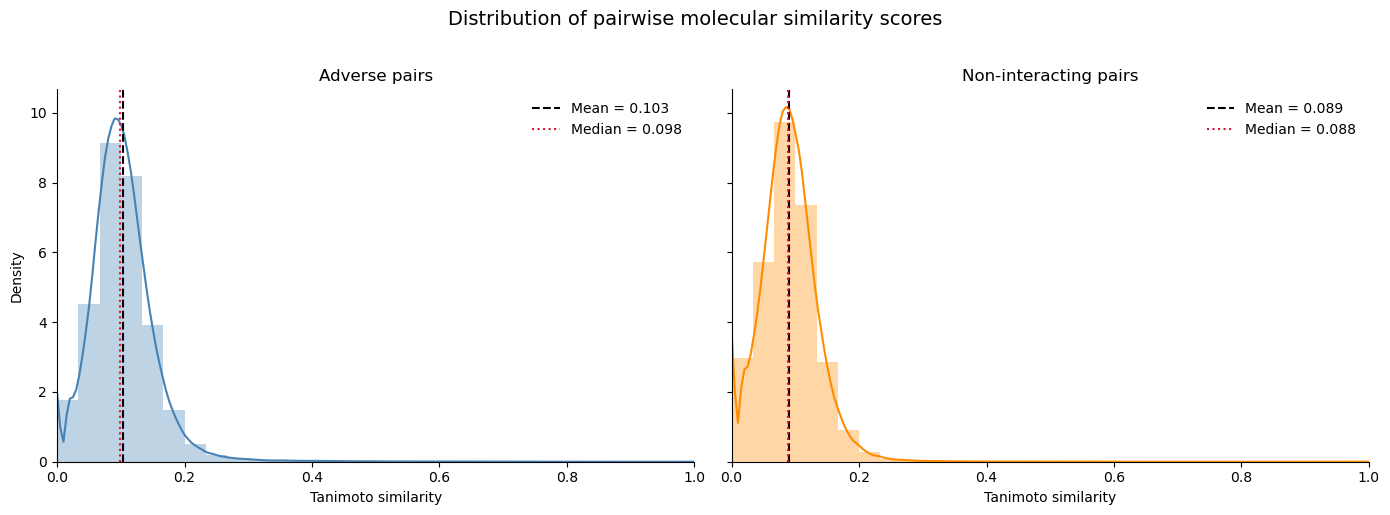

In [9]:
import matplotlib.pyplot as plt


def summarize_similarity_distribution(df, label):
    """Return a compact summary table for a similarity-score distribution."""
    scores = df["similarity_score"].astype(float)
    return pd.Series(
        {
            "dataset": label,
            "n": scores.shape[0],
            "mean": scores.mean(),
            "median": scores.median(),
            "std": scores.std(ddof=1),
            "min": scores.min(),
            "q1": scores.quantile(0.25),
            "q3": scores.quantile(0.75),
            "max": scores.max(),
            "p10": scores.quantile(0.10),
            "p90": scores.quantile(0.90),
            "pct_zero": (scores.eq(0).mean() * 100),
            "pct_ge_0_5": (scores.ge(0.5).mean() * 100),
        }
    )


similarity_summary_df = pd.DataFrame(
    [
        summarize_similarity_distribution(adverse_pairs_similarity_df, "adverse"),
        summarize_similarity_distribution(non_interacting_pairs_similarity_df, "non_interacting"),
    ]
)

display(similarity_summary_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

plot_specs = [
    (adverse_pairs_similarity_df, "Adverse pairs", "steelblue"),
    (non_interacting_pairs_similarity_df, "Non-interacting pairs", "darkorange"),
]

for ax, (dataframe, title, color) in zip(axes, plot_specs):
    scores = dataframe["similarity_score"].astype(float)
    sns.histplot(
        scores,
        bins=30,
        kde=True,
        stat="density",
        color=color,
        alpha=0.35,
        edgecolor=None,
        ax=ax,
    )
    ax.axvline(scores.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean = {scores.mean():.3f}")
    ax.axvline(scores.median(), color="crimson", linestyle=":", linewidth=1.5, label=f"Median = {scores.median():.3f}")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Tanimoto similarity")
    ax.set_ylabel("Density")
    ax.legend(frameon=False)

fig.suptitle("Distribution of pairwise molecular similarity scores", y=1.02, fontsize=14)
sns.despine()
plt.tight_layout()

comparison_df = similarity_summary_df.set_index("dataset")[["mean", "median", "std", "pct_zero", "pct_ge_0_5"]].round(3)
display(comparison_df)

## POTENTIAL CONCLUSION:  Drugs in adverse pairs have a more similar chemical structure